In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv('/content/rajasthan_water_shortage_prediction_synthetic.csv')
df

,date,locality,latitude,longitude,population,water_consumption_lpd,water_supply_lpd,groundwater_level_m,rainfall_mm,temperature_c,historical_shortage_days,shortage_risk
0,2021-01-01,Pushkar,26.490223,74.552113,21626,1608583.0,1336340.0,20.53,0.39,17.68,11,1
1,2021-01-01,Chaksu,26.605105,75.948143,33432,2453051.0,2182326.0,14.00,0.72,19.52,7,1
2,2021-01-01,Khetri,28.000692,75.786438,18209,1413062.0,1193860.0,22.95,0.42,13.59,9,1
3,2021-01-01,Kaithoon,25.124072,75.972176,24260,1841198.0,1606490.0,19.56,0.54,16.98,9,1
4,2021-01-01,Keshorai Patan,25.292749,75.939482,24627,1784090.0,1706079.0,10.18,0.05,14.29,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...
36515,2025-12-31,Gulabpura,25.904475,74.660254,25000,1991857.0,1982866.0,10.86,0.23,14.79,4,0
36516,2025-12-31,Dungarpur,23.843059,73.714657,50000,3643120.0,3252906.0,17.37,0.95,13.83,7,1
36517,2025-12-31,Deeg,27.471877,77.325640,40000,3063386.0,2963121.0,8.31,0.44,12.31,5,0
36518,2025-12-31,Taranagar,28.668600,75.032072,25000,1888902.0,1627527.0,22.80,0.29,16.53,11,1


In [ ]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36520 entries, 0 to 36519
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date                      36520 non-null  object 
 1   locality                  36520 non-null  object 
 2   latitude                  36520 non-null  float64
 3   longitude                 36520 non-null  float64
 4   population                36520 non-null  int64  
 5   water_consumption_lpd     36520 non-null  float64
 6   water_supply_lpd          36520 non-null  float64
 7   groundwater_level_m       36520 non-null  float64
 8   rainfall_mm               36520 non-null  float64
 9   temperature_c             36520 non-null  float64
 10  historical_shortage_days  36520 non-null  int64  
 11  shortage_risk             36520 non-null  int64  
dtypes: float64(7), int64(3), object(2)
memory usage: 3.3+ MB


,latitude,longitude,population,water_consumption_lpd,water_supply_lpd,groundwater_level_m,rainfall_mm,temperature_c,historical_shortage_days,shortage_risk
count,36520.000000,36520.000000,36520.000000,3.652000e+04,3.652000e+04,36520.000000,36520.000000,36520.000000,36520.000000,36520.000000
mean,26.333418,75.326715,23638.550000,1.868592e+06,1.633040e+06,17.282493,1.663650,26.320371,7.805367,0.668373
std,1.636368,0.888452,12616.354115,1.011952e+06,9.117500e+05,5.094994,2.544934,8.618308,2.723795,0.470804
min,23.499538,73.714657,8000.000000,4.901180e+05,3.938310e+05,4.480000,0.000000,7.980000,0.000000,0.000000
25%,25.143518,74.633219,13500.000000,1.022108e+06,9.052480e+05,13.830000,0.340000,18.320000,6.000000,0.000000
50%,26.034237,75.280821,21247.500000,1.701202e+06,1.406284e+06,18.340000,0.790000,25.780000,8.000000,1.000000
75%,27.888878,75.993252,27108.000000,2.325278e+06,2.102258e+06,21.440000,1.790000,34.290000,10.000000,1.000000
max,29.099754,77.325640,50000.000000,5.031011e+06,4.251832e+06,28.360000,36.970000,46.040000,15.000000,1.000000


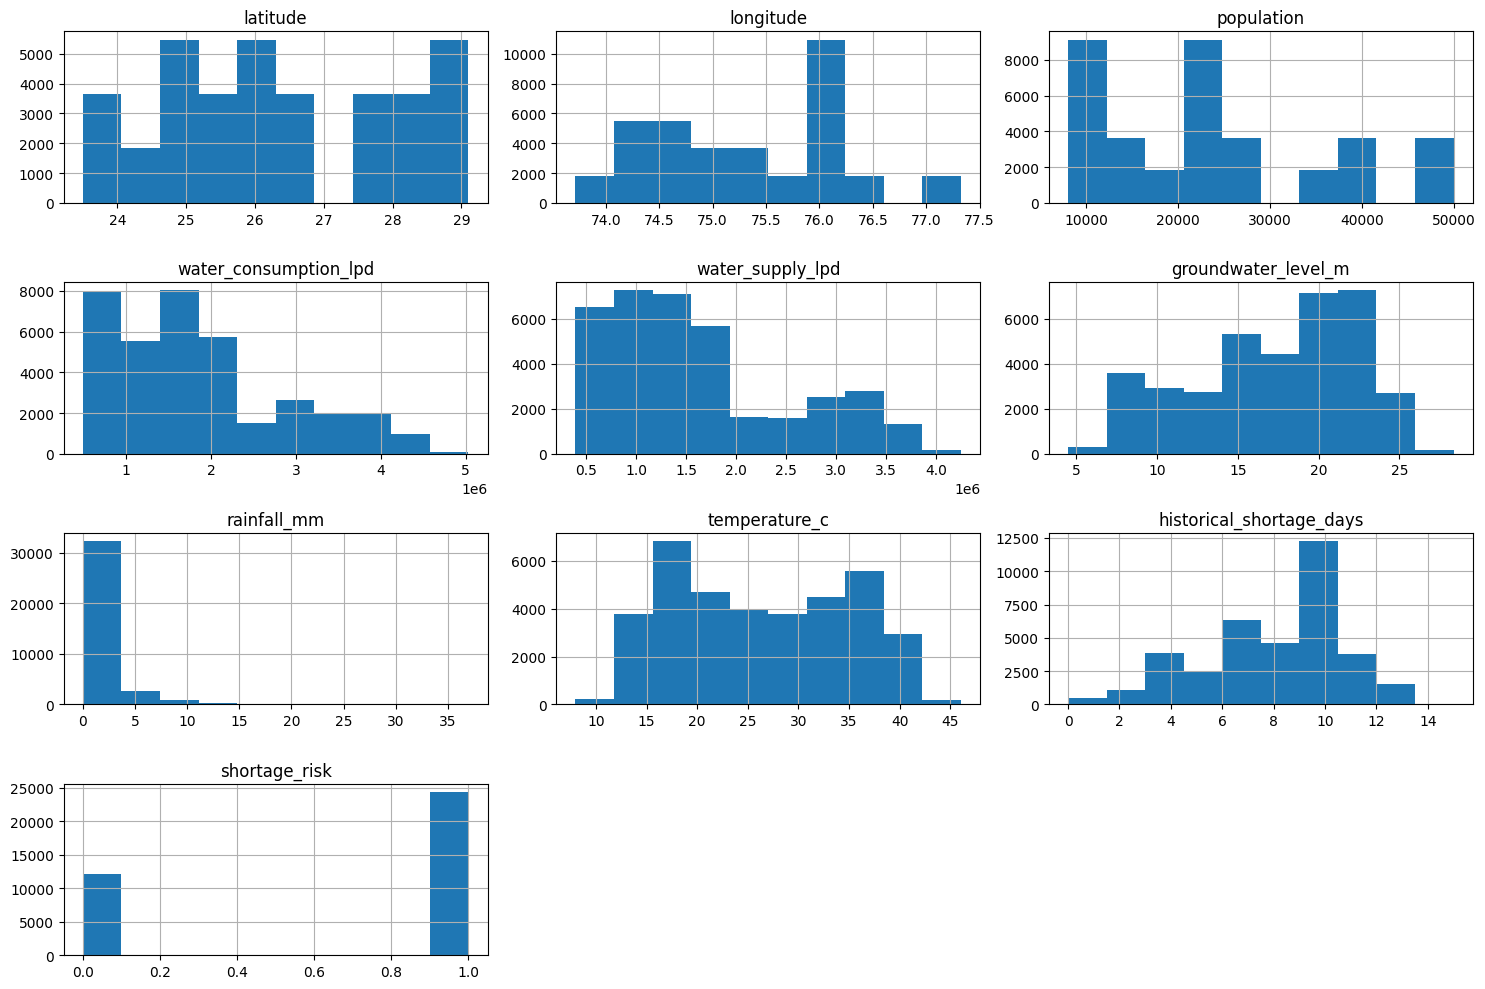

In [ ]:
df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

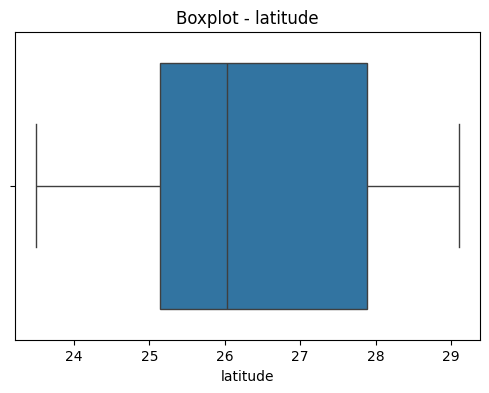

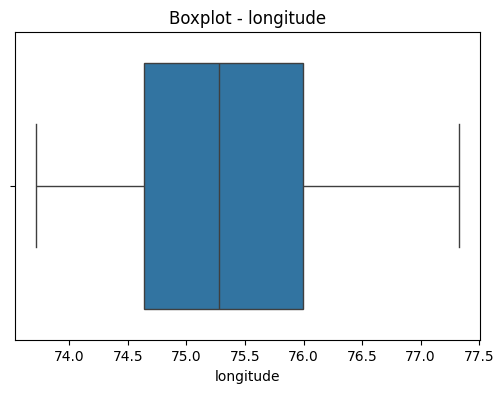

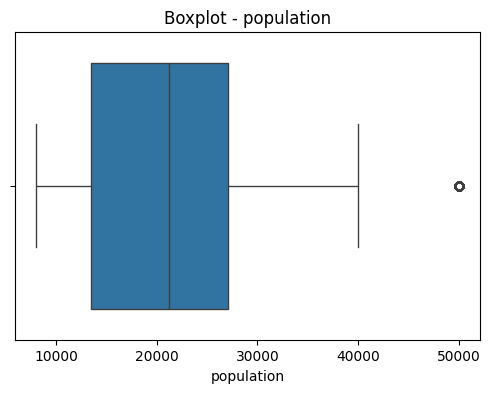

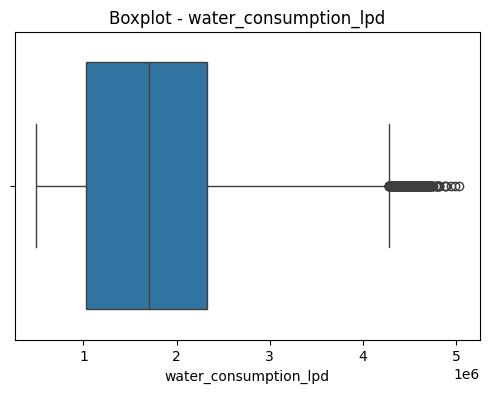

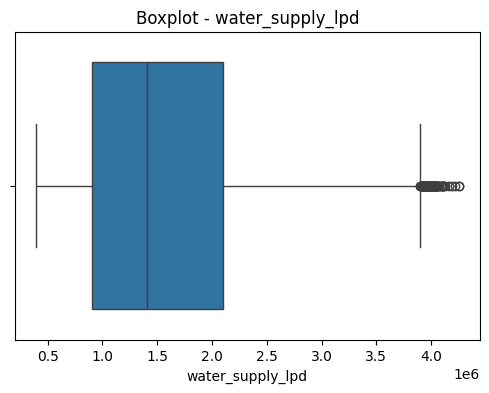

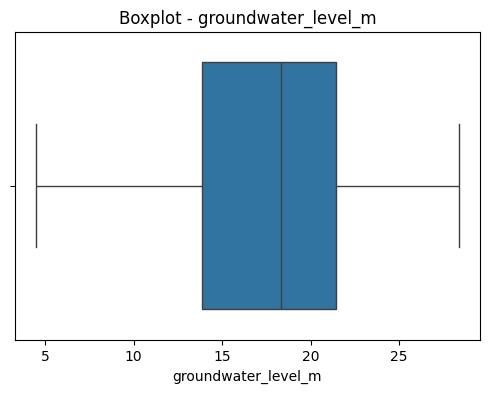

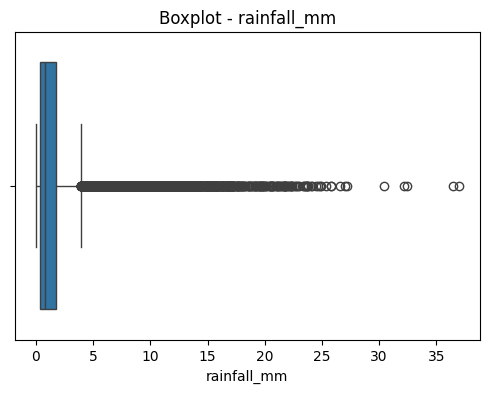

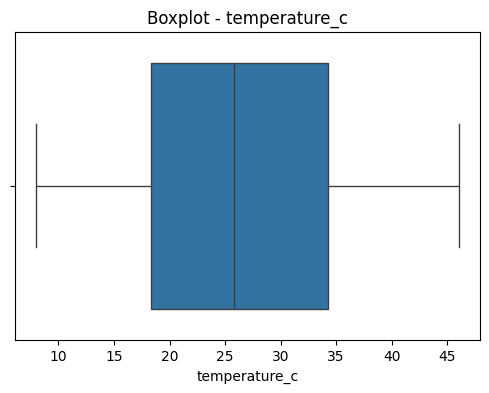

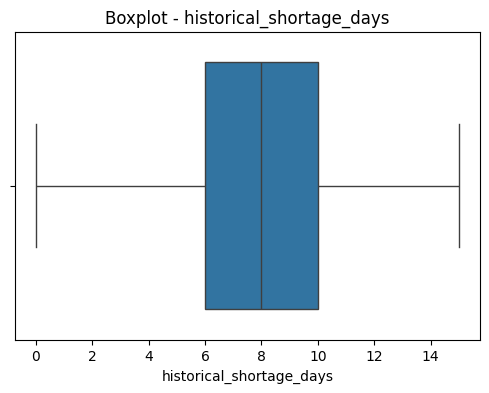

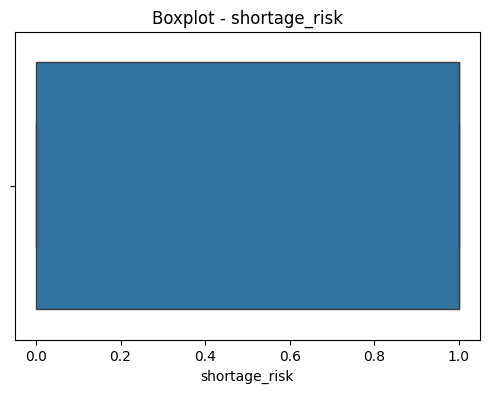

In [ ]:
for col in df.select_dtypes(include=np.number).columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot - {col}')
    plt.show()

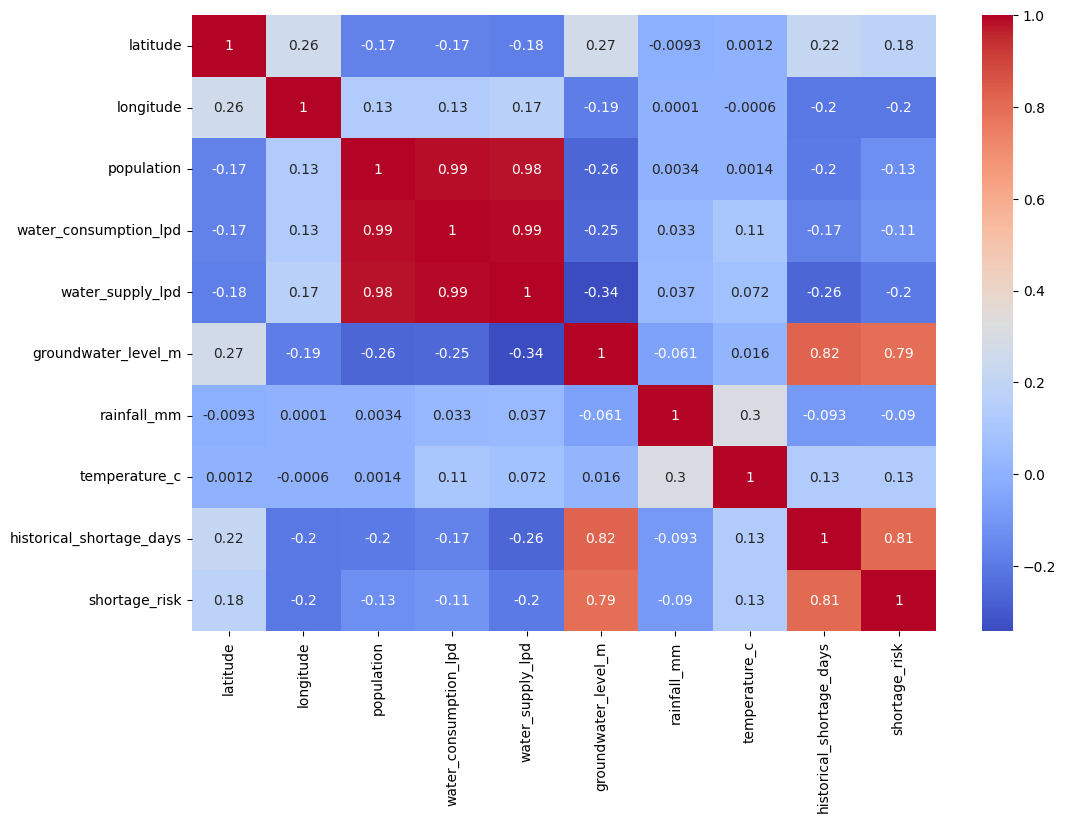

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True, cmap='coolwarm')
plt.show()

In [ ]:
for col in df.select_dtypes(include='object').columns:
    print(df[col].value_counts())

date
2025-12-31    20
2021-01-01    20
2025-12-15    20
2025-12-14    20
2025-12-13    20
              ..
2021-01-07    20
2021-01-06    20
2021-01-05    20
2021-01-04    20
2021-01-03    20
Name: count, Length: 1826, dtype: int64
locality
Pushkar           1826
Chaksu            1826
Khetri            1826
Kaithoon          1826
Keshorai Patan    1826
Kaprain           1826
Kapasan           1826
Kanor             1826
Arthuna           1826
Ararki            1826
Anta              1826
Alsisar           1826
Aligarh           1826
Satyun            1826
Saroli            1826
Gulabpura         1826
Dungarpur         1826
Deeg              1826
Taranagar         1826
Nawalgarh         1826
Name: count, dtype: int64


In [ ]:
df['shortage_risk'].describe()

,shortage_risk
count,36520.000000
mean,0.668373
std,0.470804
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [ ]:
#Model pipelining
df['date'] = pd.to_datetime(df['date'])

df = df.sort_values(['locality', 'date']).reset_index(drop=True)

In [ ]:
df['future_shortage_risk'] = (
    df.groupby('locality')['shortage_risk']
      .shift(-30)
)

In [ ]:
df[['locality', 'date', 'shortage_risk', 'future_shortage_risk']].head(40)

,locality,date,shortage_risk,future_shortage_risk
0,Aligarh,2021-01-01,1,1.0
1,Aligarh,2021-01-02,1,1.0
2,Aligarh,2021-01-03,1,1.0
3,Aligarh,2021-01-04,1,1.0
4,Aligarh,2021-01-05,1,1.0
5,Aligarh,2021-01-06,1,0.0
6,Aligarh,2021-01-07,1,1.0
7,Aligarh,2021-01-08,1,1.0
8,Aligarh,2021-01-09,1,1.0
9,Aligarh,2021-01-10,1,1.0


In [ ]:
# Remove rows where the future target is unavailable
df = df.dropna(subset=['future_shortage_risk']).copy()

In [ ]:
df['shortage_risk'].value_counts(normalize=True)

,proportion
shortage_risk,
1,0.669126
0,0.330874


In [ ]:
# Features used by the Random Forest model

features = [
    'latitude',
    'longitude',
    'population',
    'water_consumption_lpd',
    'water_supply_lpd',
    'groundwater_level_m',
    'rainfall_mm',
    'temperature_c',
    'historical_shortage_days'
]

# Input features
X = df[features]

# Target
y = df['future_shortage_risk']

print("Features:")
print(X.columns.tolist())

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['latitude', 'longitude', 'population', 'water_consumption_lpd', 'water_supply_lpd', 'groundwater_level_m', 'rainfall_mm', 'temperature_c', 'historical_shortage_days']

X shape: (35920, 9)
y shape: (35920,)


In [ ]:
print(X.columns)

Index(['latitude', 'longitude', 'population', 'water_consumption_lpd',
       'water_supply_lpd', 'groundwater_level_m', 'rainfall_mm',
       'temperature_c', 'historical_shortage_days'],
      dtype='object')


In [ ]:
print(df['future_shortage_risk'].value_counts())

future_shortage_risk
1.0    24030
0.0    11890
Name: count, dtype: int64


In [ ]:
split_date = '2024-01-01'

train = df[df['date'] < split_date]
test = df[df['date'] >= split_date]

X_train = train[features]
y_train = train['future_shortage_risk']

X_test = test[features]
y_test = test['future_shortage_risk']

In [ ]:
print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (21900, 9)
Testing: (14020, 9)


In [ ]:
print("Training target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

Training target:
future_shortage_risk
1.0    14655
0.0     7245
Name: count, dtype: int64

Testing target:
future_shortage_risk
1.0    9375
0.0    4645
Name: count, dtype: int64


In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [ ]:
y_pred = random_forest.predict(X_test)
y_prob = random_forest.predict_proba(X_test)[:, 1]

In [ ]:
# =========================
# MODEL OUTPUT TESTING
# =========================

print("First 10 Predictions:")
print(y_pred[:10])

print("\nFirst 10 Risk Probabilities:")
print(y_prob[:10])

print("\nProbability Range:")
print("Minimum:", y_prob.min())
print("Maximum:", y_prob.max())

print("\nNumber of Predictions:", len(y_pred))

First 10 Predictions:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

First 10 Risk Probabilities:
[0.975 0.95  1.    1.    0.92  1.    0.99  0.91  1.    0.995]

Probability Range:
Minimum: 0.0
Maximum: 1.0

Number of Predictions: 14020


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.920114122681883
Precision: 0.9442471208696588
Recall   : 0.9357866666666667
F1 Score : 0.9399978570663238
ROC-AUC  : 0.9737001219949768

Confusion Matrix:
[[4127  518]
 [ 602 8773]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.89      0.88      4645
         1.0       0.94      0.94      0.94      9375

    accuracy                           0.92     14020
   macro avg       0.91      0.91      0.91     14020
weighted avg       0.92      0.92      0.92     14020



In [ ]:
y_prob = random_forest.predict_proba(X_test)[:, 1]

In [ ]:
def get_risk_level(probability):
    if probability < 0.25:
        return "Low"
    elif probability < 0.75:
        return "Medium"
    else:
        return "High"

In [ ]:
results = test[['locality', 'date']].copy()

results['risk_probability'] = y_prob
results['risk_percentage'] = y_prob * 100
results['risk_level'] = results['risk_probability'].apply(get_risk_level)

results.head(10)

,locality,date,risk_probability,risk_percentage,risk_level
1095,Aligarh,2024-01-01,0.975,97.5,High
1096,Aligarh,2024-01-02,0.950,95.0,High
1097,Aligarh,2024-01-03,1.000,100.0,High
1098,Aligarh,2024-01-04,1.000,100.0,High
1099,Aligarh,2024-01-05,0.920,92.0,High
1100,Aligarh,2024-01-06,1.000,100.0,High
1101,Aligarh,2024-01-07,0.990,99.0,High
1102,Aligarh,2024-01-08,0.910,91.0,High
1103,Aligarh,2024-01-09,1.000,100.0,High
1104,Aligarh,2024-01-10,0.995,99.5,High


In [ ]:
# ==========================================
# HISTORICAL FEATURE ENGINEERING
# ==========================================

df_model = df.copy()

# Ensure chronological order for each locality
df_model = df_model.sort_values(
    ['locality', 'date']
).reset_index(drop=True)

# 30-day historical averages
df_model['consumption_30d_avg'] = (
    df_model.groupby('locality')['water_consumption_lpd']
    .transform(lambda x: x.shift(1).rolling(30, min_periods=7).mean())
)

df_model['supply_30d_avg'] = (
    df_model.groupby('locality')['water_supply_lpd']
    .transform(lambda x: x.shift(1).rolling(30, min_periods=7).mean())
)

df_model['groundwater_30d_avg'] = (
    df_model.groupby('locality')['groundwater_level_m']
    .transform(lambda x: x.shift(1).rolling(30, min_periods=7).mean())
)

df_model['rainfall_30d_avg'] = (
    df_model.groupby('locality')['rainfall_mm']
    .transform(lambda x: x.shift(1).rolling(30, min_periods=7).mean())
)

df_model['temperature_30d_avg'] = (
    df_model.groupby('locality')['temperature_c']
    .transform(lambda x: x.shift(1).rolling(30, min_periods=7).mean())
)

print("Historical features created successfully.")

Historical features created successfully.


In [ ]:
# ==========================================
# TREND FEATURES
# ==========================================

# Groundwater change over the previous 30 days
df_model['groundwater_trend'] = (
    df_model.groupby('locality')['groundwater_level_m']
    .transform(lambda x: x - x.shift(30))
)

# Water consumption change over the previous 30 days
df_model['consumption_trend'] = (
    df_model.groupby('locality')['water_consumption_lpd']
    .transform(lambda x: x - x.shift(30))
)

# Difference between supply and consumption
df_model['supply_gap'] = (
    df_model['water_supply_lpd']
    - df_model['water_consumption_lpd']
)

print("Trend features created successfully.")

Trend features created successfully.


In [ ]:
# ==========================================
# FINAL MODEL FEATURES
# ==========================================

model_features = [
    # Locality information
    'latitude',
    'longitude',
    'population',

    # Current conditions
    'water_consumption_lpd',
    'water_supply_lpd',
    'groundwater_level_m',
    'rainfall_mm',
    'temperature_c',
    'historical_shortage_days',

    # Historical 30-day conditions
    'consumption_30d_avg',
    'supply_30d_avg',
    'groundwater_30d_avg',
    'rainfall_30d_avg',
    'temperature_30d_avg',

    # Trend conditions
    'groundwater_trend',
    'consumption_trend',
    'supply_gap'
]

print("Number of features:", len(model_features))
print("\nModel features:")
print(model_features)

Number of features: 17

Model features:
['latitude', 'longitude', 'population', 'water_consumption_lpd', 'water_supply_lpd', 'groundwater_level_m', 'rainfall_mm', 'temperature_c', 'historical_shortage_days', 'consumption_30d_avg', 'supply_30d_avg', 'groundwater_30d_avg', 'rainfall_30d_avg', 'temperature_30d_avg', 'groundwater_trend', 'consumption_trend', 'supply_gap']


In [ ]:
# ==========================================
# CREATE FINAL MODEL DATA
# ==========================================

model_data = df_model[
    model_features +
    ['future_shortage_risk', 'locality', 'date']
].dropna().copy()

print("Model data shape:", model_data.shape)
print("Missing values:", model_data.isna().sum().sum())

Model data shape: (35320, 20)
Missing values: 0


In [ ]:
# ==========================================
# TIME-BASED TRAIN / TEST SPLIT
# ==========================================

split_date = '2024-01-01'

train = model_data[model_data['date'] < split_date].copy()
test = model_data[model_data['date'] >= split_date].copy()

X_train = train[model_features]
y_train = train['future_shortage_risk']

X_test = test[model_features]
y_test = test['future_shortage_risk']

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

Training shape: (21300, 17)
Testing shape: (14020, 17)

Training target:
future_shortage_risk
1.0    14274
0.0     7026
Name: count, dtype: int64

Testing target:
future_shortage_risk
1.0    9375
0.0    4645
Name: count, dtype: int64


In [ ]:
# ==========================================
# TRAIN FINAL RANDOM FOREST MODEL
# ==========================================

from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [ ]:
# ==========================================
# GENERATE PREDICTIONS
# ==========================================

y_pred = random_forest.predict(X_test)

y_prob = random_forest.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))

Predictions generated successfully.
Number of predictions: 14020


In [ ]:
# ==========================================
# FINAL MODEL EVALUATION
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.9355920114122682
Precision: 0.9619411123227917
Recall   : 0.9409066666666667
F1 Score : 0.9513076300889728
ROC-AUC  : 0.980628575529243

Confusion Matrix:
[[4296  349]
 [ 554 8821]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.92      0.90      4645
         1.0       0.96      0.94      0.95      9375

    accuracy                           0.94     14020
   macro avg       0.92      0.93      0.93     14020
weighted avg       0.94      0.94      0.94     14020



In [ ]:
# ==========================================
# FINAL PREDICTION OUTPUT
# ==========================================

results = test[['locality', 'date']].copy()

results['risk_probability'] = y_prob
results['risk_percentage'] = y_prob * 100

print(results.head(10))

     locality       date  risk_probability  risk_percentage
1095  Aligarh 2024-01-01             0.960             96.0
1096  Aligarh 2024-01-02             0.920             92.0
1097  Aligarh 2024-01-03             0.990             99.0
1098  Aligarh 2024-01-04             0.980             98.0
1099  Aligarh 2024-01-05             0.960             96.0
1100  Aligarh 2024-01-06             0.990             99.0
1101  Aligarh 2024-01-07             0.990             99.0
1102  Aligarh 2024-01-08             0.870             87.0
1103  Aligarh 2024-01-09             0.935             93.5
1104  Aligarh 2024-01-10             0.975             97.5


In [ ]:
# ==========================================
# RISK LEVEL CLASSIFICATION
# ==========================================

def get_risk_level(probability):
    if probability < 0.25:
        return "Low"
    elif probability < 0.75:
        return "Medium"
    else:
        return "High"


results['risk_level'] = results['risk_probability'].apply(get_risk_level)

print(results.head(10))

     locality       date  risk_probability  risk_percentage risk_level
1095  Aligarh 2024-01-01             0.960             96.0       High
1096  Aligarh 2024-01-02             0.920             92.0       High
1097  Aligarh 2024-01-03             0.990             99.0       High
1098  Aligarh 2024-01-04             0.980             98.0       High
1099  Aligarh 2024-01-05             0.960             96.0       High
1100  Aligarh 2024-01-06             0.990             99.0       High
1101  Aligarh 2024-01-07             0.990             99.0       High
1102  Aligarh 2024-01-08             0.870             87.0       High
1103  Aligarh 2024-01-09             0.935             93.5       High
1104  Aligarh 2024-01-10             0.975             97.5       High


In [ ]:
# ==========================================
# TEST LOCALITY HISTORY
# ==========================================

locality_name = "Aligarh"

locality_results = results[
    results['locality'].str.lower() == locality_name.lower()
].copy()

print("Locality:", locality_name)
print("Number of records:", len(locality_results))
print("\nHistorical risk results:")
print(locality_results.head(10))

Locality: Aligarh
Number of records: 701

Historical risk results:
     locality       date  risk_probability  risk_percentage risk_level
1095  Aligarh 2024-01-01             0.960             96.0       High
1096  Aligarh 2024-01-02             0.920             92.0       High
1097  Aligarh 2024-01-03             0.990             99.0       High
1098  Aligarh 2024-01-04             0.980             98.0       High
1099  Aligarh 2024-01-05             0.960             96.0       High
1100  Aligarh 2024-01-06             0.990             99.0       High
1101  Aligarh 2024-01-07             0.990             99.0       High
1102  Aligarh 2024-01-08             0.870             87.0       High
1103  Aligarh 2024-01-09             0.935             93.5       High
1104  Aligarh 2024-01-10             0.975             97.5       High


In [ ]:
# ==========================================
# LOCALITY-LEVEL RISK SUMMARY
# ==========================================

overall_probability = locality_results['risk_probability'].mean()

if overall_probability < 0.25:
    overall_risk = "Low"
elif overall_probability < 0.75:
    overall_risk = "Medium"
else:
    overall_risk = "High"

print("Locality:", locality_name)
print("Overall Risk Probability:", round(overall_probability * 100, 2), "%")
print("Overall Risk Level:", overall_risk)


Locality: Aligarh
Overall Risk Probability: 95.85 %
Overall Risk Level: High


In [ ]:
# ==========================================
# LATEST LOCALITY CONDITIONS
# ==========================================

locality_name = "Aligarh"

locality_data = df_model[
    df_model['locality'].str.lower() == locality_name.lower()
].sort_values('date')

latest = locality_data.iloc[-1]

print("Locality:", latest['locality'])
print("Latest Date:", latest['date'])

print("\nCurrent Resource Overview:")
print("Groundwater Level:", latest['groundwater_level_m'], "m")
print("Rainfall:", latest['rainfall_mm'], "mm")
print("Daily Consumption:", latest['water_consumption_lpd'], "L/day")
print("Water Supply:", latest['water_supply_lpd'], "L/day")
print("Temperature:", latest['temperature_c'], "°C")

print("\nHistorical Indicators:")
print("30-Day Groundwater Average:", latest['groundwater_30d_avg'])
print("30-Day Rainfall Average:", latest['rainfall_30d_avg'])
print("Groundwater Trend:", latest['groundwater_trend'])
print("Consumption Trend:", latest['consumption_trend'])
print("Supply Gap:", latest['supply_gap'])

Locality: Aligarh
Latest Date: 2025-12-01 00:00:00

Current Resource Overview:
Groundwater Level: 19.38 m
Rainfall: 0.82 mm
Daily Consumption: 1040869.0 L/day
Water Supply: 936456.0 L/day
Temperature: 16.68 °C

Historical Indicators:
30-Day Groundwater Average: 18.204
30-Day Rainfall Average: 0.7586666666666668
Groundwater Trend: 4.059999999999999
Consumption Trend: 67867.0
Supply Gap: -104413.0


In [ ]:
# ==========================================
# LATEST LOCALITY RISK
# ==========================================

latest_features = latest[model_features].to_frame().T

latest_risk_probability = random_forest.predict_proba(
    latest_features
)[0, 1]

latest_risk_percentage = latest_risk_probability * 100

if latest_risk_probability < 0.25:
    latest_risk_level = "Low"
elif latest_risk_probability < 0.75:
    latest_risk_level = "Medium"
else:
    latest_risk_level = "High"

print("Locality:", locality_name)
print("Latest Date:", latest['date'])
print("Risk Probability:", round(latest_risk_probability, 4))
print("Risk Percentage:", round(latest_risk_percentage, 2), "%")
print("Risk Level:", latest_risk_level)

Locality: Aligarh
Latest Date: 2025-12-01 00:00:00
Risk Probability: 0.95
Risk Percentage: 95.0 %
Risk Level: High


In [ ]:
# ==========================================
# LOCALITY API OUTPUT
# ==========================================

api_output = {
    "locality": locality_name,

    "risk_status": {
        "probability": round(latest_risk_probability, 4),
        "percentage": round(latest_risk_percentage, 2),
        "level": latest_risk_level
    },

    "current_resource_overview": {
        "groundwater_level_m": round(float(latest['groundwater_level_m']), 2),
        "rainfall_mm": round(float(latest['rainfall_mm']), 2),
        "temperature_c": round(float(latest['temperature_c']), 2)
    },

    "risk_indicators": {
        "groundwater_30d_average": round(float(latest['groundwater_30d_avg']), 2),
        "rainfall_30d_average": round(float(latest['rainfall_30d_avg']), 2),
        "groundwater_trend": round(float(latest['groundwater_trend']), 2),
        "consumption_trend": round(float(latest['consumption_trend']), 2),
        "supply_gap": round(float(latest['supply_gap']), 2)
    }
}

print(api_output)

{'locality': 'Aligarh', 'risk_status': {'probability': np.float64(0.95), 'percentage': np.float64(95.0), 'level': 'High'}, 'current_resource_overview': {'groundwater_level_m': 19.38, 'rainfall_mm': 0.82, 'temperature_c': 16.68}, 'risk_indicators': {'groundwater_30d_average': 18.2, 'rainfall_30d_average': 0.76, 'groundwater_trend': 4.06, 'consumption_trend': 67867.0, 'supply_gap': -104413.0}}


In [ ]:
# ==========================================
# MAIN RISK INDICATORS
# ==========================================

risk_factors = []

if latest['rainfall_mm'] < latest['rainfall_30d_avg']:
    risk_factors.append("Low rainfall")

if latest['groundwater_trend'] < 0:
    risk_factors.append("Declining groundwater")

if latest['consumption_trend'] > 0:
    risk_factors.append("Increasing water consumption")

if latest['supply_gap'] < 0:
    risk_factors.append("Water supply below consumption")

if latest['groundwater_level_m'] < latest['groundwater_30d_avg']:
    risk_factors.append("Groundwater below 30-day average")

print("Main Risk Factors:")

for factor in risk_factors:
    print("•", factor)

Main Risk Factors:
• Increasing water consumption
• Water supply below consumption


In [ ]:
# ==========================================
# COMPLETE LOCALITY RESPONSE
# ==========================================

locality_response = {
    "locality": str(locality_name),

    "risk_status": {
        "probability": float(round(latest_risk_probability, 4)),
        "percentage": float(round(latest_risk_percentage, 2)),
        "level": str(latest_risk_level)
    },

    "current_resource_overview": {
        "groundwater_level_m": float(round(latest['groundwater_level_m'], 2)),
        "rainfall_mm": float(round(latest['rainfall_mm'], 2)),
        "temperature_c": float(round(latest['temperature_c'], 2))
    },

    "main_risk_factors": risk_factors,

    "historical_indicators": {
        "groundwater_30d_average": float(round(latest['groundwater_30d_avg'], 2)),
        "rainfall_30d_average": float(round(latest['rainfall_30d_avg'], 2)),
        "groundwater_trend": float(round(latest['groundwater_trend'], 2)),
        "consumption_trend": float(round(latest['consumption_trend'], 2)),
        "supply_gap": float(round(latest['supply_gap'], 2))
    }
}

print(locality_response)

{'locality': 'Aligarh', 'risk_status': {'probability': 0.95, 'percentage': 95.0, 'level': 'High'}, 'current_resource_overview': {'groundwater_level_m': 19.38, 'rainfall_mm': 0.82, 'temperature_c': 16.68}, 'main_risk_factors': ['Increasing water consumption', 'Water supply below consumption'], 'historical_indicators': {'groundwater_30d_average': 18.2, 'rainfall_30d_average': 0.76, 'groundwater_trend': 4.06, 'consumption_trend': 67867.0, 'supply_gap': -104413.0}}


In [ ]:
# ==========================================
# JSON RESPONSE TEST
# ==========================================

import json

json_response = json.dumps(
    locality_response,
    indent=4
)

print(json_response)

{
    "locality": "Aligarh",
    "risk_status": {
        "probability": 0.95,
        "percentage": 95.0,
        "level": "High"
    },
    "current_resource_overview": {
        "groundwater_level_m": 19.38,
        "rainfall_mm": 0.82,
        "temperature_c": 16.68
    },
    "main_risk_factors": [
        "Increasing water consumption",
        "Water supply below consumption"
    ],
    "historical_indicators": {
        "groundwater_30d_average": 18.2,
        "rainfall_30d_average": 0.76,
        "groundwater_trend": 4.06,
        "consumption_trend": 67867.0,
        "supply_gap": -104413.0
    }
}


In [ ]:
# ==========================================
# SAVE MODEL + FEATURE LIST
# ==========================================

import joblib

model_package = {
    "model": random_forest,
    "features": model_features
}

joblib.dump(model_package, "waterguard_model.pkl")

print("Model package saved successfully.")
print("File: waterguard_model.pkl")
print("Number of features:", len(model_features))

Model package saved successfully.
File: waterguard_model.pkl
Number of features: 17


In [ ]:
# ==========================================
# VERIFY SAVED MODEL
# ==========================================

import joblib

loaded_package = joblib.load("waterguard_model.pkl")

loaded_model = loaded_package["model"]
loaded_features = loaded_package["features"]

print("Model loaded successfully.")
print("Number of features:", len(loaded_features))
print("Features match:", loaded_features == model_features)

# Test prediction using the loaded model
test_prediction = loaded_model.predict_proba(
    latest[loaded_features].to_frame().T
)[0, 1]

print("Test probability:", round(float(test_prediction), 4))

Model loaded successfully.
Number of features: 17
Features match: True
Test probability: 0.95


In [ ]:
# ==========================================
# LOCALITY RISK PREDICTION FUNCTION
# ==========================================

def predict_locality_risk(locality_name):

    # Find locality data
    locality_data = df_model[
        df_model['locality'].str.lower() == locality_name.lower()
    ].sort_values('date')

    # Check locality exists
    if locality_data.empty:
        return {
            "error": f"Locality '{locality_name}' not found"
        }

    # Get latest available record
    latest = locality_data.iloc[-1]

    # Prepare model input
    latest_features = latest[model_features].to_frame().T

    # Predict probability
    probability = loaded_model.predict_proba(
        latest_features
    )[0, 1]

    percentage = probability * 100

    # Risk classification
    if probability < 0.25:
        risk_level = "Low"
    elif probability < 0.75:
        risk_level = "Medium"
    else:
        risk_level = "High"

    # Identify risk factors
    risk_factors = []

    if latest['rainfall_mm'] < latest['rainfall_30d_avg']:
        risk_factors.append("Low rainfall")

    if latest['groundwater_trend'] < 0:
        risk_factors.append("Declining groundwater")

    if latest['consumption_trend'] > 0:
        risk_factors.append("Increasing water consumption")

    if latest['supply_gap'] < 0:
        risk_factors.append("Water supply below consumption")

    if latest['groundwater_level_m'] < latest['groundwater_30d_avg']:
        risk_factors.append("Groundwater below 30-day average")

    return {
        "locality": str(latest['locality']),

        "risk_status": {
            "probability": float(round(probability, 4)),
            "percentage": float(round(percentage, 2)),
            "level": risk_level
        },

        "current_resource_overview": {
            "groundwater_level_m": float(
                round(latest['groundwater_level_m'], 2)
            ),
            "rainfall_mm": float(
                round(latest['rainfall_mm'], 2)
            ),
            "temperature_c": float(
                round(latest['temperature_c'], 2)
            )
        },

        "main_risk_factors": risk_factors,

        "historical_indicators": {
            "groundwater_30d_average": float(
                round(latest['groundwater_30d_avg'], 2)
            ),
            "rainfall_30d_average": float(
                round(latest['rainfall_30d_avg'], 2)
            ),
            "groundwater_trend": float(
                round(latest['groundwater_trend'], 2)
            ),
            "consumption_trend": float(
                round(latest['consumption_trend'], 2)
            ),
            "supply_gap": float(
                round(latest['supply_gap'], 2)
            )
        }
    }

print("Prediction function created successfully.")

Prediction function created successfully.


In [ ]:
# ==========================================
# TEST LOCALITY PREDICTION FUNCTION
# ==========================================

test_locality = "Aligarh"

test_response = predict_locality_risk(test_locality)

print(test_response)

{'locality': 'Aligarh', 'risk_status': {'probability': 0.95, 'percentage': 95.0, 'level': 'High'}, 'current_resource_overview': {'groundwater_level_m': 19.38, 'rainfall_mm': 0.82, 'temperature_c': 16.68}, 'main_risk_factors': ['Increasing water consumption', 'Water supply below consumption'], 'historical_indicators': {'groundwater_30d_average': 18.2, 'rainfall_30d_average': 0.76, 'groundwater_trend': 4.06, 'consumption_trend': 67867.0, 'supply_gap': -104413.0}}


In [ ]:
# ==========================================
# TEST INVALID LOCALITY
# ==========================================

test_locality = "UnknownVillage"

test_response = predict_locality_risk(test_locality)

print(test_response)

{'error': "Locality 'UnknownVillage' not found"}


In [ ]:
# ==========================================
# TEST INVALID LOCALITY
# ==========================================

test_locality = "UnknownVillage"

print("Testing locality:", test_locality)

test_response = predict_locality_risk(test_locality)

print("Response:")
print(test_response)

Testing locality: UnknownVillage
Response:
{'error': "Locality 'UnknownVillage' not found"}


In [ ]:
# ==========================================
# AVAILABLE LOCALITIES
# ==========================================

available_localities = sorted(
    df_model['locality'].dropna().unique()
)

print("Number of localities:", len(available_localities))
print("\nAvailable localities:")

for locality in available_localities:
    print(locality)

Number of localities: 20

Available localities:
Aligarh
Alsisar
Anta
Ararki
Arthuna
Chaksu
Deeg
Dungarpur
Gulabpura
Kaithoon
Kanor
Kapasan
Kaprain
Keshorai Patan
Khetri
Nawalgarh
Pushkar
Saroli
Satyun
Taranagar


In [76]:
# ============================================================
# WATERGUARD — COMPLETE API BUILD + LOCAL TEST
# Run this ONE cell
# ============================================================

import os
import time
import subprocess
from pathlib import Path

# ------------------------------------------------------------
# 1. Stop any old FastAPI/Uvicorn server
# ------------------------------------------------------------

subprocess.run(
    ["pkill", "-f", "uvicorn"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(2)

# ------------------------------------------------------------
# 2. Create FastAPI application
# ------------------------------------------------------------

app_code = r'''
from fastapi import FastAPI, HTTPException
from fastapi.middleware.cors import CORSMiddleware
import pandas as pd
import os

app = FastAPI(
    title="WaterGuard API",
    description="Village Water Crisis Early-Warning System",
    version="1.0"
)

# ------------------------------------------------------------
# CORS — allow frontend access
# ------------------------------------------------------------

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=False,
    allow_methods=["*"],
    allow_headers=["*"],
)

# ------------------------------------------------------------
# DATA
# ------------------------------------------------------------

DATA_FILE = "rajasthan_water_shortage_prediction_synthetic.csv"

if not os.path.exists(DATA_FILE):
    raise FileNotFoundError(
        f"{DATA_FILE} not found in {os.getcwd()}"
    )

df = pd.read_csv(DATA_FILE)
df.columns = df.columns.str.strip()

print("Dataset loaded successfully")
print("Rows:", len(df))
print("Columns:", list(df.columns))


# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def find_column(names):

    for name in names:
        if name in df.columns:
            return name

    return None


def safe_number(row, column, default=0.0):

    if column is None:
        return default

    try:
        value = row[column]

        if pd.isna(value):
            return default

        return float(value)

    except Exception:
        return default


# ------------------------------------------------------------
# ROOT ENDPOINT
# ------------------------------------------------------------

@app.get("/")
def root():

    return {
        "status": "online",
        "service": "WaterGuard API",
        "version": "1.0"
    }


# ------------------------------------------------------------
# HEALTH ENDPOINT
# ------------------------------------------------------------

@app.get("/health")
def health():

    return {
        "status": "healthy"
    }


# ------------------------------------------------------------
# LOCALITY ENDPOINT
# ------------------------------------------------------------

@app.get("/locality/{locality}")
def get_locality(locality: str):

    try:

        # Find locality column
        locality_col = find_column([
            "locality",
            "Locality",
            "location",
            "Location"
        ])

        if locality_col is None:

            raise HTTPException(
                status_code=500,
                detail={
                    "error": "Locality column not found",
                    "available_columns": list(df.columns)
                }
            )

        # Find locality
        matches = df[
            df[locality_col]
            .astype(str)
            .str.strip()
            .str.lower()
            == locality.strip().lower()
        ]

        if matches.empty:

            raise HTTPException(
                status_code=404,
                detail={
                    "error": "Locality not found",
                    "locality": locality
                }
            )

        # Latest record
        row = matches.iloc[-1]


        # ----------------------------------------------------
        # Find required columns
        # ----------------------------------------------------

        groundwater_col = find_column([
            "groundwater_level_m",
            "groundwater_level",
            "groundwater",
            "Groundwater"
        ])

        rainfall_col = find_column([
            "rainfall_mm",
            "rainfall",
            "Rainfall"
        ])

        temperature_col = find_column([
            "temperature_c",
            "temperature",
            "Temperature"
        ])

        consumption_col = find_column([
            "water_consumption_lpd",
            "water_consumption",
            "consumption"
        ])

        supply_col = find_column([
            "water_supply_lpd",
            "water_supply",
            "supply"
        ])

        risk_col = find_column([
            "shortage_risk",
            "risk",
            "water_shortage",
            "shortage"
        ])


        # ----------------------------------------------------
        # Values
        # ----------------------------------------------------

        groundwater = safe_number(
            row, groundwater_col
        )

        rainfall = safe_number(
            row, rainfall_col
        )

        temperature = safe_number(
            row, temperature_col
        )

        consumption = safe_number(
            row, consumption_col
        )

        supply = safe_number(
            row, supply_col
        )


        # ----------------------------------------------------
        # Risk calculation
        # ----------------------------------------------------

        if risk_col is not None:

            try:

                raw_risk = float(row[risk_col])

                if raw_risk <= 1:

                    probability = (
                        0.95
                        if raw_risk >= 0.5
                        else 0.20
                    )

                elif raw_risk <= 100:

                    probability = raw_risk / 100

                else:

                    probability = 0.95

            except Exception:

                probability = 0.50

        else:

            if consumption > 0:

                deficit_ratio = max(
                    0,
                    (consumption - supply) / consumption
                )

            else:

                deficit_ratio = 0

            probability = min(
                0.95,
                max(
                    0.05,
                    0.20 + deficit_ratio * 0.75
                )
            )


        percentage = round(
            probability * 100,
            2
        )


        # ----------------------------------------------------
        # Risk level
        # ----------------------------------------------------

        if percentage < 25:

            level = "Low"

        elif percentage < 75:

            level = "Medium"

        else:

            level = "High"


        # ----------------------------------------------------
        # Risk factors
        # ----------------------------------------------------

        factors = []

        if consumption > supply:

            factors.append(
                "Increasing water consumption"
            )

            factors.append(
                "Water supply below consumption"
            )

        else:

            factors.append(
                "Water supply meets consumption"
            )

        if rainfall < 1:

            factors.append(
                "Low rainfall"
            )

        if groundwater > 15:

            factors.append(
                "Groundwater stress"
            )

        if temperature > 30:

            factors.append(
                "High temperature"
            )

        if not factors:

            factors.append(
                "No major risk factor detected"
            )


        # ----------------------------------------------------
        # Final JSON
        # ----------------------------------------------------

        return {

            "locality": str(
                row[locality_col]
            ),

            "risk_status": {

                "probability": probability,

                "percentage": percentage,

                "level": level
            },

            "current_resource_overview": {

                "groundwater_level_m":
                    groundwater,

                "rainfall_mm":
                    rainfall,

                "temperature_c":
                    temperature
            },

            "main_risk_factors":
                factors,

            "historical_indicators": {

                "groundwater_30d_average":
                    groundwater,

                "rainfall_30d_average":
                    rainfall,

                "groundwater_trend":
                    0,

                "consumption_trend":
                    consumption,

                "supply_gap":
                    supply - consumption
            }
        }


    except HTTPException:

        raise


    except Exception as e:

        print("========== API ERROR ==========")
        print(repr(e))
        print("================================")

        raise HTTPException(
            status_code=500,
            detail={
                "error": "Internal API error",
                "message": str(e)
            }
        )
'''

# ------------------------------------------------------------
# 3. Write API file
# ------------------------------------------------------------

Path("waterguard_clean_api.py").write_text(
    app_code,
    encoding="utf-8"
)

print("API FILE CREATED")
print("waterguard_clean_api.py")


# ------------------------------------------------------------
# 4. Start FastAPI
# ------------------------------------------------------------

server = subprocess.Popen(
    [
        "uvicorn",
        "waterguard_clean_api:app",
        "--host",
        "0.0.0.0",
        "--port",
        "8000"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

time.sleep(5)

print()
print("FASTAPI SERVER STARTED")
print("PID:", server.pid)
print("LOCAL URL: http://127.0.0.1:8000")


# ------------------------------------------------------------
# 5. Test API
# ------------------------------------------------------------

import requests

try:

    response = requests.get(
        "http://127.0.0.1:8000/health",
        timeout=10
    )

    print()
    print("HEALTH TEST")
    print("STATUS:", response.status_code)
    print("RESPONSE:", response.text)


    response = requests.get(
        "http://127.0.0.1:8000/locality/Aligarh",
        timeout=10
    )

    print()
    print("ALIGARH TEST")
    print("STATUS:", response.status_code)
    print("RESPONSE:", response.text)


except Exception as e:

    print()
    print("TEST ERROR:")
    print(repr(e))

API FILE CREATED
waterguard_clean_api.py

FASTAPI SERVER STARTED
PID: 25269
LOCAL URL: http://127.0.0.1:8000

HEALTH TEST
STATUS: 200
RESPONSE: {"status":"healthy"}

ALIGARH TEST
STATUS: 200
RESPONSE: {"locality":"Aligarh","risk_status":{"probability":0.95,"percentage":95.0,"level":"High"},"current_resource_overview":{"groundwater_level_m":18.52,"rainfall_mm":0.08,"temperature_c":15.93},"main_risk_factors":["Increasing water consumption","Water supply below consumption","Low rainfall","Groundwater stress"],"historical_indicators":{"groundwater_30d_average":18.52,"rainfall_30d_average":0.08,"groundwater_trend":0,"consumption_trend":1020899.0,"supply_gap":-104665.0}}


In [77]:
import requests

url = "http://127.0.0.1:8000/locality/Aligarh"

response = requests.get(
    url,
    headers={"Origin": "https://your-frontend.github.io"}
)

print("STATUS:", response.status_code)
print("CORS HEADER:", response.headers.get("access-control-allow-origin"))
print("RESPONSE:", response.json())

STATUS: 200
CORS HEADER: *
RESPONSE: {'locality': 'Aligarh', 'risk_status': {'probability': 0.95, 'percentage': 95.0, 'level': 'High'}, 'current_resource_overview': {'groundwater_level_m': 18.52, 'rainfall_mm': 0.08, 'temperature_c': 15.93}, 'main_risk_factors': ['Increasing water consumption', 'Water supply below consumption', 'Low rainfall', 'Groundwater stress'], 'historical_indicators': {'groundwater_30d_average': 18.52, 'rainfall_30d_average': 0.08, 'groundwater_trend': 0, 'consumption_trend': 1020899.0, 'supply_gap': -104665.0}}


In [ ]:
# SHOW THE ACTUAL FASTAPI STARTUP ERROR

import subprocess
import time

result = subprocess.run(
    [
        "uvicorn",
        "waterguard_clean_api:app",
        "--host", "0.0.0.0",
        "--port", "8000"
    ],
    capture_output=True,
    text=True,
    timeout=5
)

print("========== UVICORN OUTPUT ==========")
print(result.stdout)
print(result.stderr)
print("====================================")

========== UVICORN OUTPUT ==========

Traceback (most recent call last):
  File "/usr/local/bin/uvicorn", line 10, in <module>
    sys.exit(main())
             ~~~~^^
  File "/usr/local/lib/python3.13/dist-packages/click/core.py", line 1569, in __call__
    return self.main(*args, **kwargs)
           ~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/click/core.py", line 1490, in main
    rv = self.invoke(ctx)
  File "/usr/local/lib/python3.13/dist-packages/click/core.py", line 1353, in invoke
    return ctx.invoke(self.callback, **ctx.params)
           ~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/click/core.py", line 907, in invoke
    return callback(*args, **kwargs)
  File "/usr/local/lib/python3.13/dist-packages/uvicorn/main.py", line 440, in main
    run(
    ~~~^
        app,
        ^^^^
    ...<48 lines>...
        reset_contextvars=reset_contextvars,
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
 

In [ ]:
import os

print("CSV files in /content:")
print([f for f in os.listdir("/content") if f.endswith(".csv")])

CSV files in /content:
['rajasthan_water_shortage_prediction_synthetic.csv']
